# Booster Impact Tracker — Velocity Frame Edition (v2.1)

Run each cell with **Shift+Enter**.  
Change any parameter and re-run from that cell down (`Run → Run All Below`).

### Velocity-frame recap
| Symbol | Name | Description |
|--------|------|-------------|
| **γV** | Flight-path angle | Angle of velocity vector above horizontal (deg). Positive = climbing. |
| **γH** | Heading azimuth | Direction of horizontal velocity (deg). 0 = North, 90 = East. |
| **ê_t** | Tangential axis | Along velocity vector |
| **ê_nV** | Pitch-normal axis | ⊥ to velocity, upward in pitch plane — lift & pitch commands act here |
| **ê_nH** | Yaw-normal axis | Lateral direction — yaw commands act here |

### Changelog
| Version | Change |
|---------|--------|
| v2.1 | IACPN hit angle constraints (`hit_gamma_v`, `hit_gamma_h`, `hit_angle_range`); guidance active during powered flight |
| v2.0 | Velocity-frame formulation, gravity turn, lift, 3-D heading, PN guidance |

## 1 — Imports

In [ ]:
from sim.simulate import simulate
from sim.physics import Params
from plot import plot_results
from dataclasses import replace
import matplotlib.pyplot as plt
%matplotlib inline
print('Imports OK')

Imports OK


## 2 — Parameters

> **Gravity turn tip:** use `launch_angle` ≥ 85° with `grav_turn=True`.  
> At 75° the rapid pitch-over at low speed keeps max altitude very low.  
> With `grav_turn=False` any angle works (thrust held at fixed body angle).

In [ ]:
params = Params(
    # ── Booster ──────────────────────────────────────
    m_pay        = 50,     # kg  payload mass
    m_prop       = 495,    # kg  propellant mass
    m_str        = 50,     # kg  structural dry mass
    # ── Motor ────────────────────────────────────────
    isp          = 260,    # s
    thrust_kn    = 31,     # kN
    burn_max     = 20,     # s
    # ── Aerodynamics ─────────────────────────────────
    cd           = 0.4,    # drag coeff – powered
    cd_fall      = 1.2,    # drag coeff – tumbling post-burnout
    cl           = 0.0,    # lift coefficient  (0 = no lift)
    cd_ctrl      = 0.3,    # actuator drag (PN guidance)
    diam         = 0.5,    # m  reference diameter
    atm          = 'isa',  # 'isa' | 'exp' | 'none'
    # ── Launch angles ─────────────────────────────────
    launch_angle   = 45,   # deg  initial γV (elevation)
    launch_azimuth = 45,   # deg  aimed NE toward (10, 10) km target
    # ── Velocity-frame dynamics ───────────────────────
    grav_turn       = True,  # True → thrust ∥ velocity; False → fixed body angle
    grav_turn_v_min = 30.0,  # m/s  minimum speed before gravity turn activates
    a_cmd_t         = 0.0,   # m/s²  tangential accel command (ê_t)
    a_cmd_nv        = 0.0,   # m/s²  pitch-normal accel command (ê_nV)
    a_cmd_nh        = 0.0,   # m/s²  yaw-normal accel command (ê_nH)
    # ── PN/IACPN guidance target ──────────────────────
    x_target     = 10,     # km  North
    y_target     = 10,     # km  East
    z_target     = 0,      # km  altitude
    a_lat_max    = 3.0,    # g   lateral accel limit (guidance active during burn + ballistic)
    # ── Impact angle constraints (optional) ──────────
    hit_gamma_v     = None,  # deg  desired impact flight-path angle (e.g. -60); None = unconstrained
    hit_gamma_h     = None,  # deg  desired impact azimuth (e.g. 45); None = unconstrained
    hit_angle_range = None,  # km   range from target at which angle law activates; None = always
)

## 3 — Run simulation

In [ ]:
result = simulate(params)

print('=== Summary ===')
for k, v in result['summary'].items():
    print(f'  {k:<30} {v}')

=== Summary ===
  max_altitude_km                7.69
  max_velocity_ms                886.2
  max_lift_kn                    107.244
  burnout_altitude_km            1.06
  burnout_time_s                 2.4
  burnout_gamma_v_deg            90.0
  impact_x_km                    -0.05
  impact_y_km                    0.12
  impact_z_km                    7.69
  impact_range_km                0.13
  miss_distance_m                16060.0
  flight_time_s                  12000.0
  final_gamma_v_deg              90.0
  final_gamma_h_deg              138.9


## 4 — Plots (7-panel dashboard)

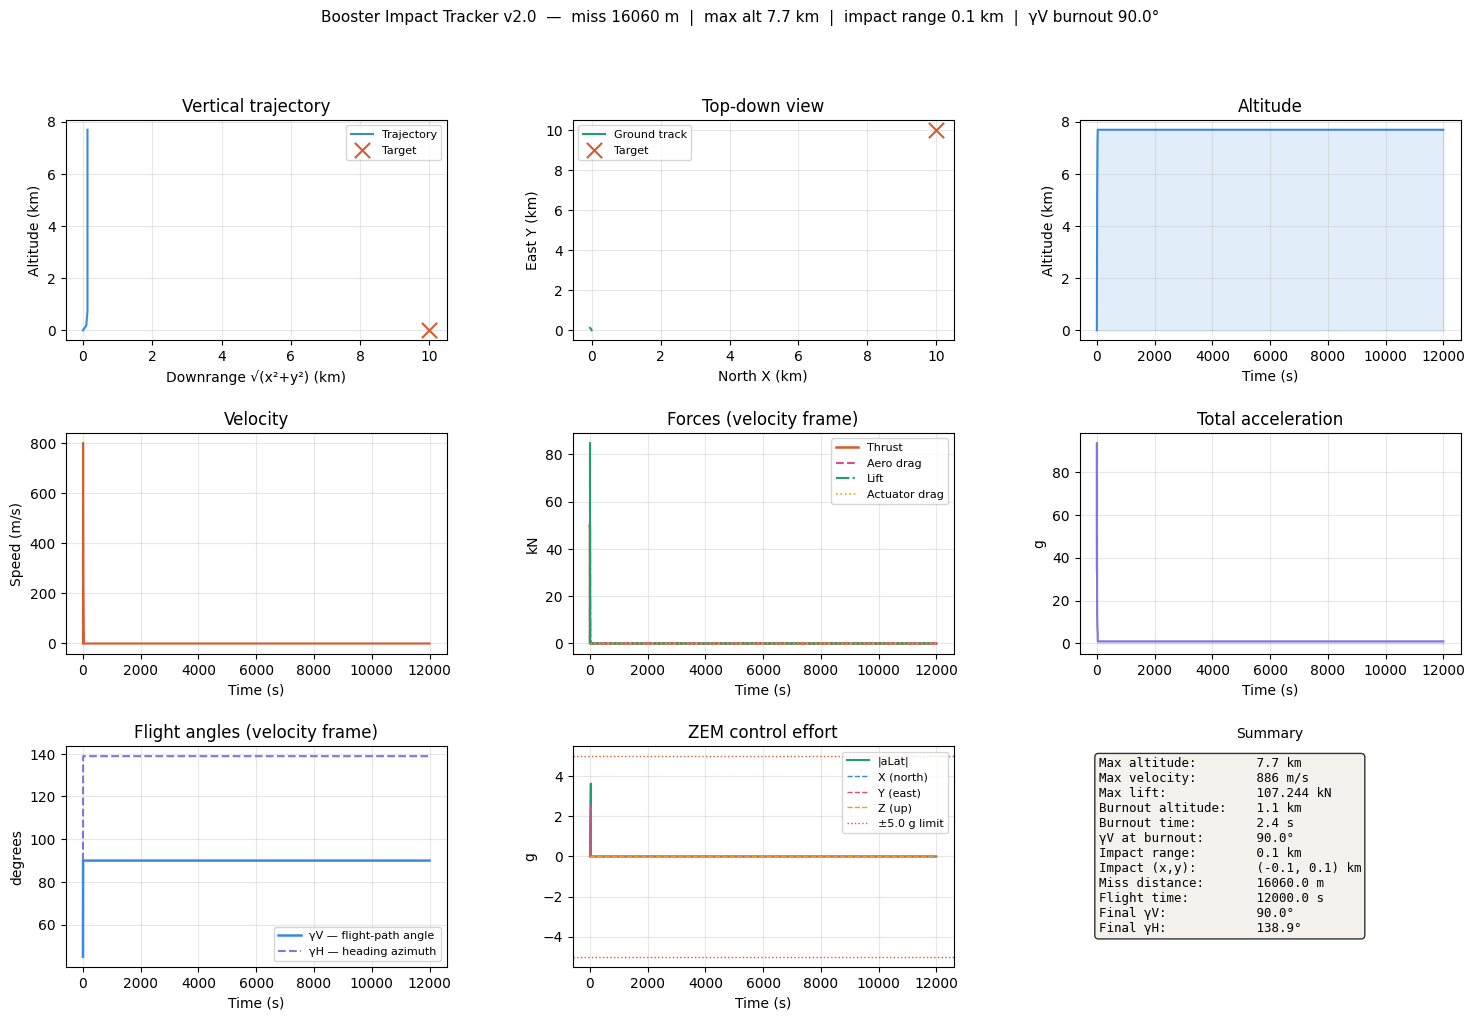

In [ ]:
plot_results(result, params)

## 5 — Inspect time-series
All arrays live in `result['series']`.

In [ ]:
s = result['series']
print('Available keys:', list(s.keys()))
print(f"Samples: {len(s['t'])}  |  Flight time: {s['t'][-1]} s")

Available keys: ['t', 'x', 'y', 'h', 'v', 'gamma_v', 'gamma_h', 'thr', 'drag_aero', 'lift', 'drag_ctrl', 'acc', 'aLat', 'aLat_x', 'aLat_y', 'aLat_z']
Samples: 12000  |  Flight time: 11999.0 s


In [ ]:
i = 10   # <-- change to inspect any timestep

print(f"t = {s['t'][i]} s")
print(f"  Position :  h={s['h'][i]} km   x={s['x'][i]} km   y={s['y'][i]} km")
print(f"  Velocity :  v={s['v'][i]} m/s")
print(f"  Frame    :  γV={s['gamma_v'][i]}°   γH={s['gamma_h'][i]}°")
print(f"  Forces   :  thrust={s['thr'][i]} kN   drag={s['drag_aero'][i]} kN   lift={s['lift'][i]} kN")
print(f"  ZEM      :  |aLat|={s['aLat'][i]} g   (nV={s['a_nV'][i]} g, nH={s['a_nH'][i]} g)")
print(f"  Accel    :  {s['acc'][i]} g")

## 6 — Flight-path angle profile (γV and γH)
Shows how the velocity-frame angles evolve over the full flight.

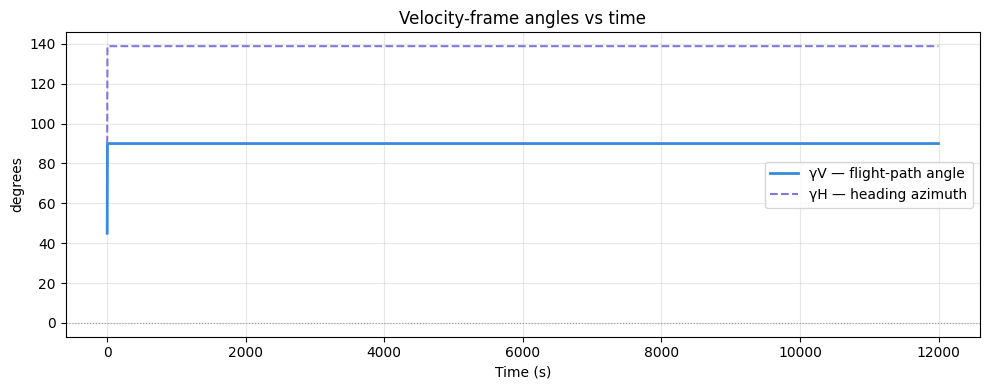

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(s['t'], s['gamma_v'], color='#378ADD', linewidth=2, label='γV — flight-path angle')
ax.plot(s['t'], s['gamma_h'], color='#7F77DD', linewidth=1.5, linestyle='--', label='γH — heading azimuth')
ax.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('degrees')
ax.set_title('Velocity-frame angles vs time')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — Gravity turn vs fixed-angle comparison
Runs the same vehicle twice and overlays the altitude and γV profiles.

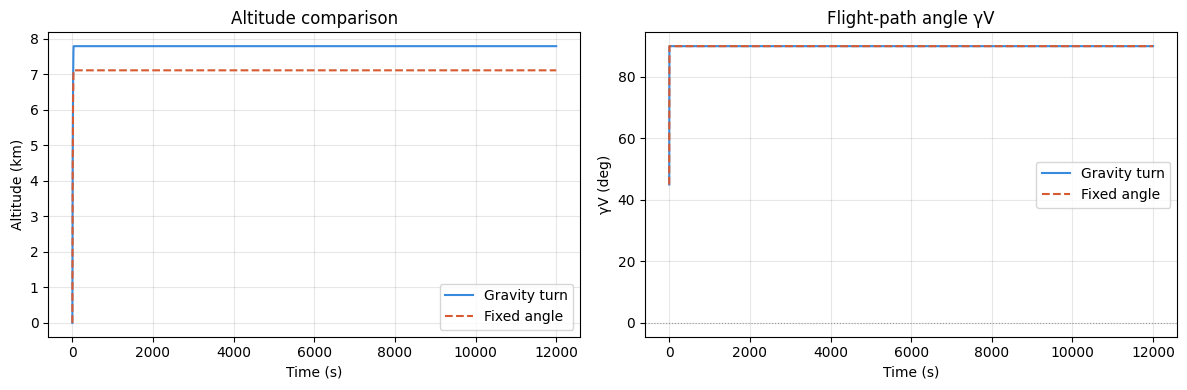

Gravity turn     max_alt=7.8 km  burnout_gV=90.0°  range=0.1 km
Fixed angle      max_alt=7.1 km  burnout_gV=90.0°  range=0.3 km


In [ ]:
r_gt  = simulate(replace(params, grav_turn=True,  a_lat_max=0))  # no ZEM, pure ballistic
r_fix = simulate(replace(params, grav_turn=False, a_lat_max=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Altitude
ax1.plot(r_gt['series']['t'],  r_gt['series']['h'],  color='#378ADD', label='Gravity turn')
ax1.plot(r_fix['series']['t'], r_fix['series']['h'], color='#D85A30', linestyle='--', label='Fixed angle')
ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude comparison'); ax1.legend(); ax1.grid(alpha=0.3)

# γV
ax2.plot(r_gt['series']['t'],  r_gt['series']['gamma_v'],  color='#378ADD', label='Gravity turn')
ax2.plot(r_fix['series']['t'], r_fix['series']['gamma_v'], color='#D85A30', linestyle='--', label='Fixed angle')
ax2.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γV (deg)')
ax2.set_title('Flight-path angle γV'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

for label, r in [('Gravity turn', r_gt), ('Fixed angle', r_fix)]:
    sm = r['summary']
    print(f"{label:<15}  max_alt={sm['max_altitude_km']:.1f} km  "
          f"burnout_gV={sm['burnout_gamma_v_deg']:.1f}°  "
          f"range={sm['impact_range_km']:.1f} km")

## 8 — Lift coefficient sweep
Shows how increasing CL slows the gravity-turn pitch-over (higher γV at burnout → more altitude).

   CL     max_alt    burnout_gV    max_lift       range
  0.0        7.53          67.4°       0.000 kN         1.1 km
  0.2        7.68          74.2°      10.801 kN         0.6 km
  0.5        7.74          84.4°      26.912 kN         0.3 km
  1.0        7.77          90.0°      53.707 kN         0.2 km


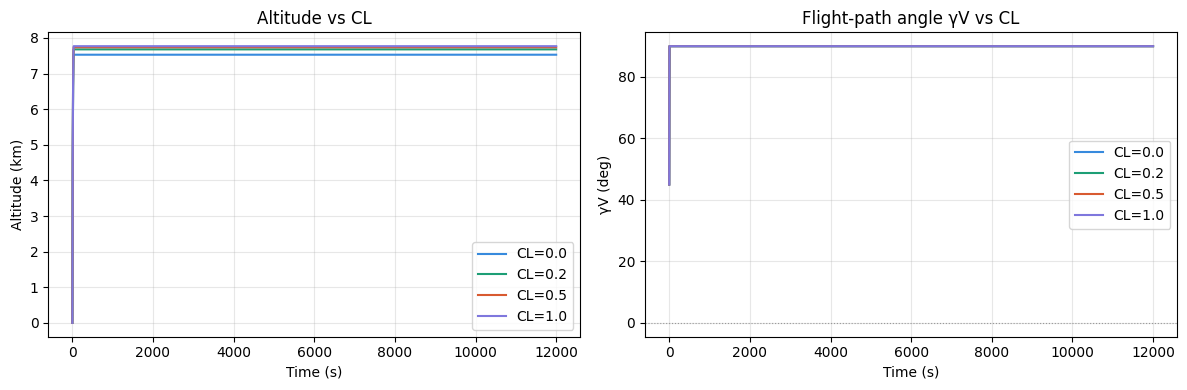

In [ ]:
cl_values = [0.0, 0.2, 0.5, 1.0]
colors     = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

print(f"{'CL':>5}  {'max_alt':>10}  {'burnout_gV':>12}  {'max_lift':>10}  {'range':>10}")
for cl, col in zip(cl_values, colors):
    r  = simulate(replace(params, cl=cl, a_lat_max=0))
    sm = r['summary']
    sv = r['series']
    ax1.plot(sv['t'], sv['h'],       color=col, label=f'CL={cl}')
    ax2.plot(sv['t'], sv['gamma_v'], color=col, label=f'CL={cl}')
    print(f"{cl:>5}  {sm['max_altitude_km']:>10.2f}  "
          f"{sm['burnout_gamma_v_deg']:>12.1f}°  "
          f"{sm['max_lift_kn']:>10.3f} kN  "
          f"{sm['impact_range_km']:>10.1f} km")

ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude vs CL'); ax1.legend(); ax1.grid(alpha=0.3)
ax2.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γV (deg)')
ax2.set_title('Flight-path angle γV vs CL'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9 — Pitch acceleration command sweep (a_cmd_nv)
`a_cmd_nv` acts along **ê_nV** (pitch-normal). Positive pulls the flight path upward, slowing the gravity-turn pitch-over.

  a_nV     max_alt    burnout_gV       range
  -2.0        7.70          90.0°         0.3 km
  +0.0        7.70          90.0°         0.3 km
  +2.0        7.71          90.0°         0.3 km
  +5.0        7.72          90.0°         0.3 km


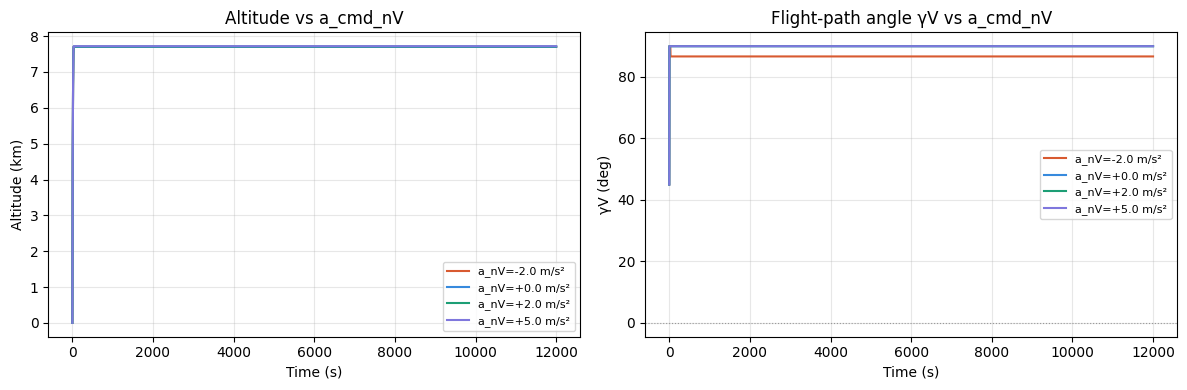

In [ ]:
nv_values = [-2.0, 0.0, 2.0, 5.0]
colors     = ['#D85A30', '#378ADD', '#1D9E75', '#7F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

print(f"{'a_nV':>6}  {'max_alt':>10}  {'burnout_gV':>12}  {'range':>10}")
for nv, col in zip(nv_values, colors):
    r  = simulate(replace(params, a_cmd_nv=nv, a_lat_max=0))
    sm = r['summary']
    sv = r['series']
    ax1.plot(sv['t'], sv['h'],       color=col, label=f'a_nV={nv:+.1f} m/s²')
    ax2.plot(sv['t'], sv['gamma_v'], color=col, label=f'a_nV={nv:+.1f} m/s²')
    print(f"{nv:>+6.1f}  {sm['max_altitude_km']:>10.2f}  "
          f"{sm['burnout_gamma_v_deg']:>12.1f}°  "
          f"{sm['impact_range_km']:>10.1f} km")

ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude vs a_cmd_nV'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.axhline(0, color='#999', linewidth=0.8, linestyle=':')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γV (deg)')
ax2.set_title('Flight-path angle γV vs a_cmd_nV'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 10 — Yaw command sweep (a_cmd_nh)
`a_cmd_nh` acts along **ê_nH** (yaw-normal). It changes γH over time, diverting the booster laterally. The impact range uses 3-D distance √(x²+y²).

  a_nH    final_gH    impact_x    impact_y       range
  +0.0        90.0°        0.00 km        0.13 km         0.1 km
  +1.0        91.0°       -0.00 km        0.13 km         0.1 km
  +3.0        92.9°       -0.00 km        0.13 km         0.1 km
  -2.0        88.0°        0.00 km        0.13 km         0.1 km


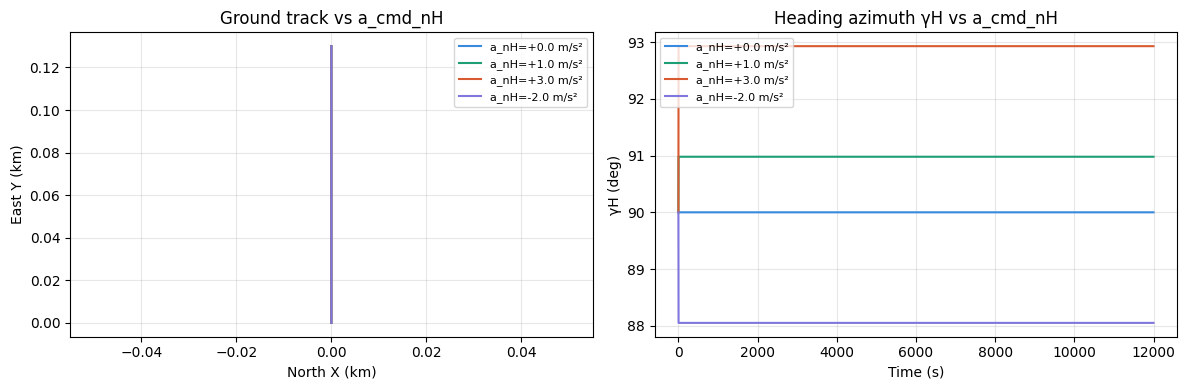

In [ ]:
import math
nh_values = [0.0, 1.0, 3.0, -2.0]
colors     = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

print(f"{'a_nH':>6}  {'final_gH':>10}  {'impact_x':>10}  {'impact_y':>10}  {'range':>10}")
for nh, col in zip(nh_values, colors):
    r  = simulate(replace(params, a_cmd_nh=nh, a_lat_max=0))
    sm = r['summary']
    sv = r['series']
    # Ground track
    ax1.plot(sv['x'], sv['y'], color=col, label=f'a_nH={nh:+.1f} m/s²')
    ax2.plot(sv['t'], sv['gamma_h'], color=col, label=f'a_nH={nh:+.1f} m/s²')
    print(f"{nh:>+6.1f}  {sm['final_gamma_h_deg']:>10.1f}°  "
          f"{sm['impact_x_km']:>10.2f} km  "
          f"{sm['impact_y_km']:>10.2f} km  "
          f"{sm['impact_range_km']:>10.1f} km")

ax1.set_xlabel('North X (km)'); ax1.set_ylabel('East Y (km)')
ax1.set_title('Ground track vs a_cmd_nH'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('γH (deg)')
ax2.set_title('Heading azimuth γH vs a_cmd_nH'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 11 — Launch angle sweep
Classic trade: higher angle → more altitude, less range.

In [ ]:
angles = [30, 45, 60, 75]

print(f"{'angle':>6}  {'max_alt':>10}  {'burnout_gV':>12}  {'burnout_alt':>12}  {'range':>10}  {'t_flight':>10}")
for angle in angles:
    r  = simulate(replace(params, launch_angle=angle, a_lat_max=0))
    sm = r['summary']
    print(f"{angle:>6}°  {sm['max_altitude_km']:>10.2f}  "
          f"{sm['burnout_gamma_v_deg']:>12.1f}°  "
          f"{sm['burnout_altitude_km']:>12.2f} km  "
          f"{sm['impact_range_km']:>10.1f} km  "
          f"{sm['flight_time_s']:>10.1f} s")

## 12 — Run check vectors (pytest)

In [ ]:
!python -m pytest tests/check_vectors.py -v

============================= test session starts =============================
platform win32 -- Python 3.12.9, pytest-9.0.2, pluggy-1.6.0 -- c:\Users\Anastasia\AppData\Local\Programs\Python\Python312\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Anastasia\OneDrive\Desktop\Satellite_sim
plugins: anyio-4.13.0
collecting ... collected 13 items

tests/check_vectors.py::TestDeterminism::test_same_params_same_result PASSED [  7%]
tests/check_vectors.py::TestPhysicsInvariants::test_vertical_launch_zero_crossrange PASSED [ 15%]
tests/check_vectors.py::TestPhysicsInvariants::test_zero_propellant_stays_on_ground PASSED [ 23%]
tests/check_vectors.py::TestPhysicsInvariants::test_vacuum_zero_aero_drag PASSED [ 30%]
tests/check_vectors.py::TestPhysicsInvariants::test_altitude_non_negative PASSED [ 38%]
tests/check_vectors.py::TestPhysicsInvariants::test_burnout_altitude_below_max PASSED [ 46%]
tests/check_vectors.py::TestGuidance::test_guidance_reduces_miss PASSED  [ 53%]
tests/check_vector

## 13 — Impact angle constraints (IACPN)

The IACPN guidance law is active **throughout the entire flight** (during burn and ballistic phases).  
It supports two optional terminal angle constraints:

| Parameter | Description |
|-----------|-------------|
| `hit_gamma_v` | Desired impact flight-path angle γV (deg). e.g. `−60` = 60° below horizontal; `−90` = vertical dive. `None` = unconstrained. |
| `hit_gamma_h` | Desired impact azimuth γH (deg). Same convention as `launch_azimuth`. `None` = unconstrained. |
| `hit_angle_range` | Range from target (km) at which the angle correction activates. Outside = pure PN; inside = IACPN. `None` = angle law always active. |

When inside the activation range, the IACPN adds a tgo-weighted correction on top of standard PN:

```
a_nV_angle = K · v · sin(hit_γV − γV_LOS) / tgo
a_nH_angle = K · v · cos(γV) · sin(hit_γH − γH_LOS) / tgo
```

> **Note:** angle constraints trade miss distance for angle compliance.

In [ ]:
from dataclasses import replace

base = Params(
    m_pay=50, m_prop=495, m_str=50, isp=260, thrust_kn=31, burn_max=20,
    cd=0.4, cd_fall=1.2, cl=0.0, cd_ctrl=0.3, diam=0.5,
    launch_angle=45, launch_azimuth=45,
    x_target=10, y_target=10, z_target=0, a_lat_max=3.0,
)

cases = [
    ('Pure PN (no angles)',         dict(hit_gamma_v=None, hit_gamma_h=None, hit_angle_range=None)),
    ('IACPN, range gate 15 km',    dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=15)),
    ('IACPN, range gate  5 km',    dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=5)),
    ('IACPN, always active',       dict(hit_gamma_v=-60,  hit_gamma_h=45,   hit_angle_range=None)),
    ('Vertical only (γV=-80)',      dict(hit_gamma_v=-80,  hit_gamma_h=None, hit_angle_range=15)),
]

print(f"{'Case':<30}  {'miss_m':>8}  {'γV_impact':>10}  {'γH_impact':>10}")
print('-' * 65)
for label, kw in cases:
    r = simulate(replace(base, **kw))
    sm = r['summary']
    print(f"{label:<30}  {sm['miss_distance_m']:>8.1f}  "
          f"{sm['final_gamma_v_deg']:>9.1f}°  "
          f"{sm['final_gamma_h_deg']:>9.1f}°")

## 14 — Guidance during powered flight
PN/IACPN is now active from ignition. This section compares trajectories with guidance on vs off during the burn to show the effect on miss distance and impact angles.

In [ ]:
import math

base = Params(
    m_pay=50, m_prop=495, m_str=50, isp=260, thrust_kn=31, burn_max=20,
    cd=0.4, cd_fall=1.2, cl=0.0, cd_ctrl=0.3, diam=0.5,
    launch_angle=45, launch_azimuth=45,
    x_target=10, y_target=10, z_target=0, a_lat_max=3.0,
)

# PN guidance — active from ignition (v2.1 behaviour)
r_guided   = simulate(base)

# Ballistic — no guidance at all
r_ballistic = simulate(replace(base, a_lat_max=0))

print(f"{'':30}  {'miss_m':>8}  {'γV_impact':>10}  {'γH_impact':>10}  {'range_km':>10}")
print('-' * 70)
for label, r in [('Guided (burn + ballistic)', r_guided),
                 ('Ballistic (no guidance)',    r_ballistic)]:
    sm = r['summary']
    print(f"{label:<30}  {sm['miss_distance_m']:>8.1f}  "
          f"{sm['final_gamma_v_deg']:>9.1f}°  "
          f"{sm['final_gamma_h_deg']:>9.1f}°  "
          f"{sm['impact_range_km']:>10.2f}")

# ── Plot: altitude and ground track ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for label, r, col, ls in [
    ('Guided',     r_guided,    '#378ADD', '-'),
    ('Ballistic',  r_ballistic, '#D85A30', '--'),
]:
    sv = r['series']
    ax1.plot(sv['t'], sv['h'], color=col, linestyle=ls, label=label)
    ax2.plot(sv['x'], sv['y'], color=col, linestyle=ls, label=label)

ax2.plot(base.x_target, base.y_target, 'k*', markersize=12, label='Target')

ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Altitude (km)')
ax1.set_title('Altitude — guided vs ballistic'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel('North X (km)'); ax2.set_ylabel('East Y (km)')
ax2.set_title('Ground track — guided vs ballistic'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()